In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("data.csv")

In [3]:
df.head()

,Unnamed: 0,cc_num,category,amt,gender,is_fraud,age,trans_month,trans_year,lat_dis,long_dis
0,0,2.703190e+15,misc_net,4.97,0,0,30,1,2019,0.067507,0.870215
1,1,6.304230e+11,grocery_pos,107.23,0,0,40,1,2019,0.271247,0.024038
2,2,3.885950e+13,entertainment,220.11,1,0,56,1,2019,0.969904,0.107519
3,3,3.534090e+15,gas_transport,45.00,1,0,52,1,2019,0.803731,0.447271
4,4,3.755340e+14,misc_pos,41.96,1,0,32,1,2019,0.254299,0.830441


In [4]:
df.tail()

,Unnamed: 0,cc_num,category,amt,gender,is_fraud,age,trans_month,trans_year,lat_dis,long_dis
4845,4845,3.401870e+14,grocery_pos,274.09,0,1,58,1,2019,0.349989,0.462803
4846,4846,3.401870e+14,grocery_pos,274.09,0,1,58,1,2019,0.349989,0.462803
4847,4847,3.401870e+14,grocery_pos,274.09,0,1,58,1,2019,0.349989,0.462803
4848,4848,3.401870e+14,grocery_pos,274.09,0,1,58,1,2019,0.349989,0.462803
4849,4849,3.401870e+14,grocery_pos,274.09,0,1,58,1,2019,0.349989,0.462803


In [5]:
df['category'].value_counts()

,count
category,
grocery_pos,1248
gas_transport,602
home,384
shopping_net,334
kids_pets,325
shopping_pos,309
personal_care,283
health_fitness,267
food_dining,251


In [10]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,3532
1,1318


In [6]:
df.isnull().sum()

,0
Unnamed: 0,0
cc_num,0
category,0
amt,0
gender,0
is_fraud,0
age,0
trans_month,0
trans_year,0
lat_dis,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4850 entries, 0 to 4849
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   4850 non-null   int64  
 1   cc_num       4850 non-null   float64
 2   category     4850 non-null   object 
 3   amt          4850 non-null   float64
 4   gender       4850 non-null   int64  
 5   is_fraud     4850 non-null   int64  
 6   age          4850 non-null   int64  
 7   trans_month  4850 non-null   int64  
 8   trans_year   4850 non-null   int64  
 9   lat_dis      4850 non-null   float64
 10  long_dis     4850 non-null   float64
dtypes: float64(4), int64(6), object(1)
memory usage: 416.9+ KB


In [8]:
df.describe()

,Unnamed: 0,cc_num,amt,gender,is_fraud,age,trans_month,trans_year,lat_dis,long_dis
count,4850.000000,4.850000e+03,4850.000000,4850.000000,4850.000000,4850.00000,4850.0,4850.0,4850.000000,4850.000000
mean,2424.500000,2.973469e+17,124.218249,0.338557,0.271753,49.48000,1.0,2019.0,0.509902,0.500396
std,1400.218733,1.118060e+18,170.548263,0.473268,0.444909,17.58814,0.0,0.0,0.275157,0.275451
min,0.000000,6.041621e+10,1.030000,0.000000,0.000000,13.00000,1.0,2019.0,0.000066,0.000352
25%,1212.250000,3.401870e+14,11.520000,0.000000,0.000000,34.00000,1.0,2019.0,0.322686,0.232301
50%,2424.500000,2.284565e+15,57.780000,0.000000,0.000000,49.00000,1.0,2019.0,0.486717,0.545954
75%,3636.750000,4.826660e+15,183.075000,1.000000,1.000000,58.00000,1.0,2019.0,0.778758,0.683791
max,4849.000000,4.992350e+18,3178.510000,1.000000,1.000000,92.00000,1.0,2019.0,0.999906,0.999807


In [9]:
df.columns

Index(['Unnamed: 0', 'cc_num', 'category', 'amt', 'gender', 'is_fraud', 'age',
       'trans_month', 'trans_year', 'lat_dis', 'long_dis'],
      dtype='object')

In [15]:
X = df[['cc_num', 'category', 'amt', 'gender','age',
       'trans_month', 'trans_year', 'lat_dis', 'long_dis']]
y = df['is_fraud']

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=8)

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
numeric_features = ['cc_num', 'amt', 'gender', 'age', 'trans_month','trans_year', 'lat_dis', 'long_dis']
categorical_features = ['category']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ])

In [18]:
from sklearn.neighbors import KNeighborsClassifier
KNN = Pipeline(steps=[('preprocessor', preprocessor),
                        ('Regressor', KNeighborsClassifier() )])
KNN.fit(X_train, y_train)

# Predict on the test set
y_pred = KNN.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
KNN_score=int(accuracy * 100)
# Print the results
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.9979381443298969
Precision: 0.9979537055047657
Recall: 0.9979381443298969
F1 Score: 0.9979405891218485


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define the pipeline with Logistic Regression
LR_model = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', LogisticRegression(max_iter=1000))])  # Increase max_iter if convergence warning occurs

# Fit the model
LR_model.fit(X_train, y_train)

# Predict on the test set
y_pred = LR_model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
LR_score = int(accuracy * 100)

# Print the results
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")


Accuracy: 0.7288659793814433
Precision: 0.5312456158996706
Recall: 0.7288659793814433
F1 Score: 0.614559627218462


In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline

# Define the pipeline with DecisionTreeClassifier
DT_model = Pipeline(steps=[('preprocessor', preprocessor),
                            ('classifier', DecisionTreeClassifier(random_state=42))])

# Fit the model
DT_model.fit(X_train, y_train)

# Predict on the test set
y_pred = DT_model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
DT_score = int(accuracy * 100)

# Print the results
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")


Accuracy: 0.9989690721649485
Precision: 0.9989729771946266
Recall: 0.9989690721649485
F1 Score: 0.9989696854737748


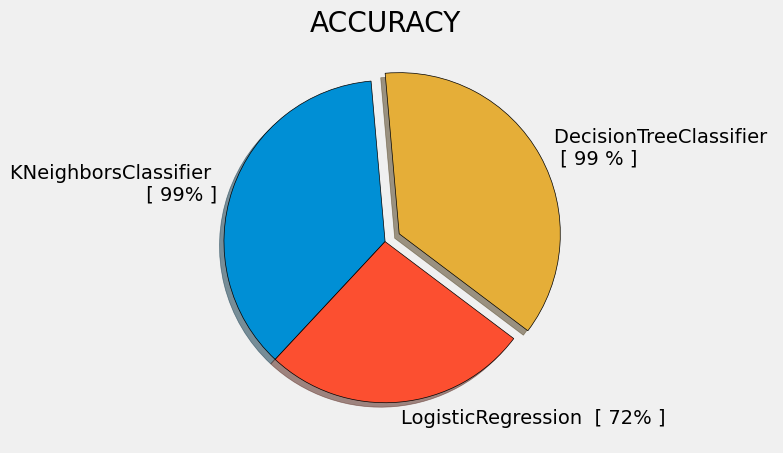

In [21]:
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Language Popularity
#python is not good with a lot of data so we shall modify our list to top 5 languages.
slices = [KNN_score, LR_score, DT_score]
labels = [f'KNeighborsClassifier \n [ {KNN_score}% ]',f'LogisticRegression  [ {LR_score}% ]',f'DecisionTreeClassifier \n [ {DT_score} % ]']
explode = [0,0, 0.1] #this puts an emphasis on python

plt.pie(slices, labels = labels, explode = explode,
        #shadow = True for asthetics to add a shadow to our plot
        shadow = True,
        #startangle = 90, rotates the original chart by 90 degress
        startangle = 95,
        wedgeprops = {'edgecolor': 'black'})



plt.title('ACCURACY')
plt.tight_layout()
plt.show()

In [22]:
df

,Unnamed: 0,cc_num,category,amt,gender,is_fraud,age,trans_month,trans_year,lat_dis,long_dis
0,0,2.703190e+15,misc_net,4.97,0,0,30,1,2019,0.067507,0.870215
1,1,6.304230e+11,grocery_pos,107.23,0,0,40,1,2019,0.271247,0.024038
2,2,3.885950e+13,entertainment,220.11,1,0,56,1,2019,0.969904,0.107519
3,3,3.534090e+15,gas_transport,45.00,1,0,52,1,2019,0.803731,0.447271
4,4,3.755340e+14,misc_pos,41.96,1,0,32,1,2019,0.254299,0.830441
...,...,...,...,...,...,...,...,...,...,...,...
4845,4845,3.401870e+14,grocery_pos,274.09,0,1,58,1,2019,0.349989,0.462803
4846,4846,3.401870e+14,grocery_pos,274.09,0,1,58,1,2019,0.349989,0.462803
4847,4847,3.401870e+14,grocery_pos,274.09,0,1,58,1,2019,0.349989,0.462803
4848,4848,3.401870e+14,grocery_pos,274.09,0,1,58,1,2019,0.349989,0.462803


In [23]:
import pickle
# Dump the trained DT classifier with Pickle
DT_filename = 'DT.pkl'
# Open the file to save as pkl file
DT_Model_pkl = open(DT_filename, 'wb')
pickle.dump(DT_model, DT_Model_pkl)
# Close the pickle instances
DT_Model_pkl.close()